# Synthetic Deal Data Generator

Generates realistic closed-won deal records with correlated features and touch timelines.
- Python generates structured skeletons with realistic distributions
- LLM fills in call summaries and contextual notes
- Output: JSON files ready for feature engineering and model training

In [1]:
import json
import random
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime, timedelta
from typing import Optional
from scipy import stats
from tqdm.notebook import tqdm

random.seed(42)
np.random.seed(42)

OUTPUT_DIR = '../backend/data/synthetic'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration — Distributions & Correlations

In [2]:
# --- Industry mix (from AskElephant customer research) ---
INDUSTRIES = [
    'SaaS/Tech',
    'Marketing Agency',
    'Fintech',
    'PropTech',
    'Healthcare IT',
    'EdTech',
    'eCommerce',
    'Managed IT/Cybersecurity',
    'Professional Services',
    'Vertical SaaS',
]

INDUSTRY_WEIGHTS = [0.20, 0.12, 0.10, 0.08, 0.10, 0.08, 0.08, 0.08, 0.10, 0.06]

# --- Segment distribution (from research) ---
# Deal ranges based on AskElephant pricing: $89/user/mo (Unlimited Automation)
# $170/user/mo (Automations + AI Consulting)
# Assumes 25-50% discounts at seed stage
# Revenue team penetration ~30-50% of revenue-facing org
SEGMENTS = {
    'smb':        {
        'pct': 0.55,
        'employees': (10, 100),
        'seats': (3, 12),            # small sales team + CS lead
        'price_per_seat': (45, 89),  # discounted
        'deal_range': (2_000, 12_000),  # annual contract value
        'cycle_weeks': (2, 6),
        'touch_count': (3, 8),
    },
    'mid_market': {
        'pct': 0.35,
        'employees': (100, 1000),
        'seats': (10, 35),           # sales + CS + RevOps teams
        'price_per_seat': (55, 89),  # some discount
        'deal_range': (8_000, 35_000),
        'cycle_weeks': (4, 12),
        'touch_count': (8, 20),
    },
    'enterprise': {
        'pct': 0.10,
        'employees': (1000, 10000),
        'seats': (25, 75),           # multiple revenue-facing teams
        'price_per_seat': (89, 170), # full price or consulting tier
        'deal_range': (30_000, 130_000),
        'cycle_weeks': (8, 26),
        'touch_count': (15, 40),
    },
}

# --- Product tiers (maps to AskElephant pricing) ---
PRODUCT_TIERS = ['unlimited_automation', 'automations_plus_consulting']
TIER_BY_SEGMENT = {
    'smb': [0.85, 0.15],
    'mid_market': [0.55, 0.45],
    'enterprise': [0.25, 0.75],
}

# --- Standard sales pipeline stages ---
SALES_STAGES = ['prospecting', 'qualification', 'discovery', 'demo_evaluation',
                'proposal', 'negotiation', 'closed_won']

# --- Touch types mapped to stages ---
TOUCH_TYPES_BY_STAGE = {
    'prospecting':      ['cold_call', 'cold_email', 'linkedin_message'],
    'qualification':    ['qualification_call', 'follow_up_email'],
    'discovery':        ['discovery_call', 'follow_up_email', 'follow_up_call'],
    'demo_evaluation':  ['demo', 'technical_eval', 'follow_up_email'],
    'proposal':         ['proposal_call', 'follow_up_email', 'exec_meeting'],
    'negotiation':      ['pricing_call', 'negotiation_call', 'follow_up_email', 'exec_meeting'],
}

# --- Typical durations by touch type (mean, std) ---
TOUCH_DURATIONS = {
    'cold_call': (0, 0),           # voicemail unless got_response
    'cold_email': (0, 0),
    'linkedin_message': (0, 0),
    'qualification_call': (15, 5),
    'discovery_call': (25, 8),
    'follow_up_call': (15, 5),
    'follow_up_email': (0, 0),
    'demo': (40, 10),
    'technical_eval': (45, 12),
    'proposal_call': (20, 7),
    'exec_meeting': (30, 10),
    'pricing_call': (20, 7),
    'negotiation_call': (25, 8),
}

# --- People roles ---
ROLES = ['champion', 'technical_evaluator', 'exec_sponsor', 'end_user', 'procurement']

# --- Lead source distribution ---
# Inbound: prospect initiated (demo request, content download, referral)
# Outbound: SDR-initiated (cold outreach)
LEAD_SOURCES = ['inbound', 'outbound']
LEAD_SOURCE_WEIGHTS_BY_SEGMENT = {
    'smb': [0.40, 0.60],        # SMBs more likely found via outbound
    'mid_market': [0.45, 0.55],  # roughly even
    'enterprise': [0.30, 0.70],  # enterprise mostly outbound/targeted
}

INBOUND_CHANNELS = ['demo_request', 'content_download', 'referral', 'webinar_signup', 'website_chat']

# --- Competitors ---
COMPETITORS = ['Gong', 'Fathom', 'Fireflies', 'Clari', 'Chorus', 'None']
COMPETITOR_WEIGHTS = [0.20, 0.15, 0.15, 0.10, 0.10, 0.30]

# --- Use cases ---
USE_CASES = [
    'CRM automation',
    'Call recording + coaching',
    'Sales-to-CS handoff',
    'Pipeline visibility',
    'Forecasting accuracy',
    'Rep productivity',
    'Onboarding automation',
]

# --- Company name parts (for realistic generation) ---
NAME_PREFIXES = [
    'Apex', 'Nova', 'Summit', 'Vertex', 'Pulse', 'Core', 'Bright', 'Scale',
    'Cloud', 'Iron', 'Swift', 'Blue', 'True', 'Peak', 'Next', 'Prime',
    'Clear', 'Forge', 'Arc', 'Zen', 'Bold', 'Atlas', 'Orbit', 'Flux',
    'Echo', 'Lunar', 'Solar', 'Nimbus', 'Quartz', 'Onyx', 'Amber', 'Cobalt',
    'Crimson', 'Ivory', 'Jade', 'Pearl', 'Ruby', 'Silver', 'Golden', 'Obsidian',
    'Northwind', 'Southpoint', 'Eastgate', 'Westfield', 'Central', 'Helix',
    'Meridian', 'Horizon', 'Pioneer', 'Sentinel', 'Beacon', 'Compass',
    'Granite', 'Oak', 'Cedar', 'Maple', 'Pine', 'Birch', 'Willow', 'Aspen',
    'Canyon', 'Ridge', 'Valley', 'Delta', 'River', 'Harbor', 'Coastal', 'Bay',
    'Stellar', 'Cosmic', 'Orbital', 'Galactic', 'Comet', 'Nebula', 'Quasar',
    'Kinetic', 'Dynamic', 'Momentum', 'Velocity', 'Pivot', 'Fusion', 'Nexus',
    'Prism', 'Vector', 'Lattice', 'Matrix', 'Vortex', 'Spiral', 'Loop',
    'Quantum', 'Photon', 'Proton', 'Ion', 'Atom', 'Plasma', 'Pixel',
    'Crimson', 'Sage', 'Violet', 'Indigo', 'Teal', 'Mint', 'Coral', 'Clay',
]
NAME_SUFFIXES = [
    'Systems', 'Labs', 'Digital', 'Tech', 'AI', 'Solutions', 'Group',
    'Software', 'Data', 'Analytics', 'Cloud', 'IO', 'Works', 'Logic',
    'Hub', 'Stack', 'Ops', 'Platform', 'Media', 'Health',
    'Apps', 'Labs', 'Partners', 'Dynamics', 'Insights', 'Networks', 'Metrics',
    'Intelligence', 'Ventures', 'Capital', 'Connect', 'Signal', 'Bridge',
    'Link', 'Flow', 'Grid', 'Core', 'Engine', 'Mint', 'Forge', 'Forward',
    'Vault', 'Axis', 'Pulse', 'Spark', 'Lens', 'Scope', 'Edge', 'Vision',
    'Agency', 'Consulting', 'Studio', 'Foundry', 'Collective', 'Co',
    'Sync', 'Relay', 'Gear', 'Form', 'Labs', 'Cube', 'Sphere', 'Prism',
    'Channel', 'Pathway', 'Gateway', 'Portal', 'Exchange', 'Market',
]

FIRST_NAMES = [
    'Sarah', 'James', 'Maria', 'David', 'Emily', 'Michael', 'Lisa', 'Chris',
    'Jessica', 'Ryan', 'Amanda', 'Kevin', 'Rachel', 'Brandon', 'Nicole',
    'Tyler', 'Lauren', 'Derek', 'Megan', 'Alex',
    'Noah', 'Olivia', 'Liam', 'Emma', 'Mason', 'Ava', 'Ethan', 'Sophia',
    'Lucas', 'Isabella', 'Aiden', 'Mia', 'Oliver', 'Amelia', 'Elijah',
    'Harper', 'Daniel', 'Charlotte', 'Benjamin', 'Evelyn', 'Jackson',
    'Abigail', 'Owen', 'Ella', 'Henry', 'Madison', 'Sebastian', 'Scarlett',
    'Jack', 'Grace', 'Carter', 'Chloe', 'Wyatt', 'Zoey', 'Samuel', 'Hannah',
    'Dylan', 'Lily', 'Nathan', 'Aria', 'Caleb', 'Layla', 'Isaac', 'Riley',
    'Luke', 'Zara', 'Mateo', 'Camila', 'Julian', 'Aaliyah', 'Leo', 'Nora',
    'Ezra', 'Penelope', 'Grayson', 'Savannah', 'Asher', 'Luna', 'Miles',
    'Priya', 'Arjun', 'Aisha', 'Omar', 'Fatima', 'Hiroshi', 'Yuki', 'Diego',
    'Valentina', 'Santiago', 'Elena', 'Mateus', 'Sofia', 'Ravi', 'Anika',
    'Ade', 'Zainab', 'Kwame', 'Amara', 'Tariq', 'Leila', 'Javier', 'Rosa',
    'Finn', 'Ruby', 'Theo', 'Ivy', 'Jude', 'Willow', 'Levi', 'Hazel',
    'Morgan', 'Taylor', 'Jordan', 'Casey', 'Avery', 'Quinn', 'Blake', 'Reese',
    'Cameron', 'Peyton', 'Dakota', 'Parker', 'Riley', 'Rowan', 'Sage',
]
LAST_NAMES = [
    'Chen', 'Patel', 'Smith', 'Johnson', 'Garcia', 'Kim', 'Williams', 'Jones',
    'Brown', 'Davis', 'Miller', 'Wilson', 'Moore', 'Taylor', 'Anderson',
    'Thomas', 'Jackson', 'White', 'Harris', 'Martin',
    'Nguyen', 'Tran', 'Le', 'Pham', 'Huang', 'Wang', 'Liu', 'Zhou', 'Sun',
    'Wu', 'Yang', 'Lee', 'Park', 'Choi', 'Jung', 'Kang', 'Yoon', 'Lim',
    'Singh', 'Kumar', 'Sharma', 'Gupta', 'Shah', 'Desai', 'Mehta', 'Reddy',
    'Iyer', 'Rao', 'Agarwal', 'Kapoor', 'Khan', 'Ahmed', 'Ali', 'Hassan',
    'Rodriguez', 'Martinez', 'Hernandez', 'Lopez', 'Gonzalez', 'Perez',
    'Sanchez', 'Ramirez', 'Torres', 'Flores', 'Rivera', 'Gomez', 'Diaz',
    'Silva', 'Santos', 'Costa', 'Almeida', 'Oliveira', 'Pereira', 'Lima',
    'Schmidt', 'Schneider', 'Fischer', 'Weber', 'Wagner', 'Becker',
    'Schulz', 'Hoffmann', 'Bauer', 'Koch', 'Richter', 'Klein', 'Wolf',
    'OConnor', 'Murphy', 'Kelly', 'Ryan', 'Walsh', 'Byrne', 'Doyle',
    'Nakamura', 'Tanaka', 'Suzuki', 'Takahashi', 'Sato', 'Ito', 'Watanabe',
    'Cohen', 'Levy', 'Friedman', 'Goldberg', 'Stern', 'Weiss', 'Katz',
    'Okafor', 'Adeyemi', 'Mensah', 'Diallo', 'Osei', 'Nkrumah', 'Abiola',
    'Clark', 'Lewis', 'Walker', 'Hall', 'Allen', 'Young', 'King', 'Wright',
    'Scott', 'Green', 'Adams', 'Baker', 'Nelson', 'Carter', 'Mitchell',
    'Campbell', 'Roberts', 'Phillips', 'Evans', 'Turner', 'Collins', 'Hill',
    'Bennett', 'Morgan', 'Rogers', 'Cooper', 'Morris', 'Watson', 'Brooks',
]

## Deal Skeleton Generator

In [3]:
def pick_segment():
    """Pick segment with dirichlet-sampled weights for natural variation."""
    # Base weights with noise — not exactly 55/35/10 every time
    base = np.array([0.55, 0.35, 0.10])
    noisy = np.random.dirichlet(base * 50)  # concentration controls variance
    return np.random.choice(['smb', 'mid_market', 'enterprise'], p=noisy)


def gen_company(segment):
    """Generate company profile with log-normal employee distribution."""
    params = SEGMENTS[segment]
    name = f"{random.choice(NAME_PREFIXES)}{random.choice(NAME_SUFFIXES)}"
    industry = random.choices(INDUSTRIES, weights=INDUSTRY_WEIGHTS, k=1)[0]
    
    # Log-normal employee count — more realistic than uniform
    low, high = params['employees']
    mu = np.log((low + high) / 2)
    sigma = 0.5
    employees = int(np.clip(np.random.lognormal(mu, sigma), low, high))
    
    # Revenue per employee — normal with variance
    rev_per_emp = np.random.normal(140_000, 40_000)
    rev_per_emp = max(60_000, rev_per_emp)
    annual_revenue = int(employees * rev_per_emp)
    
    return {
        'name': name,
        'industry': industry,
        'employee_count': employees,
        'annual_revenue': annual_revenue,
        'segment': segment,
    }


def gen_people(segment, has_exec_sponsor):
    """Generate contacts with stochastic role assignment."""
    people = []
    
    # Champion — always present
    people.append({
        'name': f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}",
        'role': 'champion',
        'title': random.choice(['VP of Sales', 'Head of Sales', 'Director of Sales',
                                'VP of CS', 'Director of CS', 'Head of RevOps']),
        'tenure_months': int(np.random.exponential(18) + 3),  # skewed right
    })
    
    if has_exec_sponsor:
        people.append({
            'name': f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}",
            'role': 'exec_sponsor',
            'title': random.choice(['CRO', 'CEO', 'COO', 'SVP of Revenue']),
            'tenure_months': int(np.random.exponential(24) + 6),
        })
    
    # Additional stakeholders — poisson distributed by segment
    extra_lambda = {'smb': 0.5, 'mid_market': 1.8, 'enterprise': 3.5}
    n_extra = np.random.poisson(extra_lambda[segment])
    
    for _ in range(n_extra):
        role = random.choice(['technical_evaluator', 'end_user', 'procurement'])
        people.append({
            'name': f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}",
            'role': role,
            'title': random.choice(['Sales Manager', 'RevOps Analyst', 'IT Director',
                                    'Account Manager', 'Implementation Lead']),
            'tenure_months': int(np.random.exponential(12) + 1),
        })
    
    return people


def gen_deal_params(segment, has_exec_sponsor, competitor):
    """Generate deal params with correlated noise — not deterministic."""
    params = SEGMENTS[segment]
    
    # Seats — truncated normal centered in the range
    seat_low, seat_high = params['seats']
    seat_mu = (seat_low + seat_high) / 2
    seat_sigma = (seat_high - seat_low) / 4
    seats = int(np.clip(np.random.normal(seat_mu, seat_sigma), seat_low, seat_high))
    
    # Price per seat — beta distribution scaled to range (skews toward discounted)
    price_low, price_high = params['price_per_seat']
    # Beta(2,3) skews toward lower prices (more discounting)
    price_frac = np.random.beta(2, 3)
    price_per_seat = price_low + price_frac * (price_high - price_low)
    
    # Amount = seats × price × 12, with some noise
    base_amount = seats * price_per_seat * 12
    # Add gaussian noise (±10%)
    amount_noise = np.random.normal(1.0, 0.05)
    amount = round(base_amount * amount_noise, -2)
    amount = max(params['deal_range'][0], min(params['deal_range'][1], amount))
    
    # Sales cycle — gamma distributed (right-skewed, realistic)
    week_low, week_high = params['cycle_weeks']
    cycle_mu = (week_low + week_high) / 2
    cycle_shape = 3  # controls skewness
    cycle_scale = cycle_mu / cycle_shape
    cycle_weeks = np.clip(np.random.gamma(cycle_shape, cycle_scale), week_low, week_high)
    
    # Competitor extends cycle — with variance
    if competitor != 'None':
        cycle_weeks += np.random.exponential(1.5)
    
    sales_cycle_days = int(cycle_weeks * 7 + np.random.normal(0, 2))
    sales_cycle_days = max(7, sales_cycle_days)
    
    # Touch count — loosely correlated with cycle, not deterministic
    touch_low, touch_high = params['touch_count']
    # Base: ~1.5 touches per week of cycle, with noise
    touch_base = cycle_weeks * np.random.normal(1.5, 0.4)
    touch_count = int(np.clip(touch_base, touch_low, touch_high))
    
    # Effective discount
    effective_discount = max(0, round((1 - price_per_seat / 89) * 100, 1))
    
    # Product tier
    tier = random.choices(PRODUCT_TIERS, weights=TIER_BY_SEGMENT[segment], k=1)[0]
    
    return {
        'amount': amount,
        'seats': seats,
        'price_per_seat_monthly': round(price_per_seat, 2),
        'effective_discount_pct': effective_discount,
        'sales_cycle_days': sales_cycle_days,
        'touch_count': touch_count,
        'product_tier': tier,
    }

## Touch Timeline Generator

In [4]:
def gen_touch_timeline(deal_params, people, close_date, lead_source='outbound', inbound_channel=None):
    """
    Generate touches following standard sales pipeline stages.
    Each touch mimics AskElephant AI-processed output format.
    """
    touch_count = deal_params['touch_count']
    cycle_days = deal_params['sales_cycle_days']
    start_date = close_date - timedelta(days=cycle_days)
    
    touches = []
    champion = next(p for p in people if p['role'] == 'champion')
    has_exec = any(p['role'] == 'exec_sponsor' for p in people)
    
    # --- Prospecting phase ---
    if lead_source == 'outbound':
        # SDR cold outreach — multiple attempts before connecting
        n_sdr = int(np.random.geometric(p=0.25))
        n_sdr = min(n_sdr, 12)
        sdr_start = start_date - timedelta(days=int(np.random.uniform(7, 30)))
        
        for i in range(n_sdr):
            touch_type = random.choice(TOUCH_TYPES_BY_STAGE['prospecting'])
            gap = int(np.random.exponential(2.5) + 1)
            touch_date = sdr_start + timedelta(days=i * gap)
            got_response = (i == n_sdr - 1)
            
            duration = 0
            if touch_type == 'cold_call' and got_response:
                duration = int(np.random.normal(5, 2))
                duration = max(2, duration)
            
            resp_time = None
            if got_response and touch_type in ('cold_email', 'linkedin_message'):
                resp_time = round(np.random.exponential(8) + 0.5, 1)
            
            touches.append({
                'touch_number': i + 1,
                'date': touch_date.strftime('%Y-%m-%d'),
                'type': touch_type,
                'duration_minutes': duration,
                'person_name': champion['name'],
                'person_role': champion['role'],
                'person_title': champion['title'],
                'stage': 'prospecting',
                'got_response': got_response,
                'response_time_hours': resp_time,
                'rescheduled': False,
                'ai_summary': None,
                'questions_asked': [],
                'objections': [],
                'next_steps': [],
                'sentiment': None,
            })
    else:
        # Inbound — prospect initiated, skip cold outreach
        inbound_date = start_date - timedelta(days=int(np.random.uniform(1, 7)))
        touches.append({
            'touch_number': 1,
            'date': inbound_date.strftime('%Y-%m-%d'),
            'type': 'inbound_request',
            'duration_minutes': 0,
            'person_name': champion['name'],
            'person_role': champion['role'],
            'person_title': champion['title'],
            'stage': 'prospecting',
            'got_response': True,
            'response_time_hours': round(np.random.exponential(2) + 0.5, 1),
            'rescheduled': False,
            'ai_summary': None,
            'questions_asked': [],
            'objections': [],
            'next_steps': [],
            'sentiment': None,
            'inbound_channel': inbound_channel,
        })
    
    # --- Active pipeline touches ---
    active_stages = ['qualification', 'discovery', 'demo_evaluation', 'proposal', 'negotiation']
    
    for i in range(touch_count):
        progress = i / max(touch_count - 1, 1)
        
        # Map progress to stage with fuzzy boundaries
        stage_noise = np.random.normal(0, 0.05)
        adj = progress + stage_noise
        if adj < 0.15:
            stage = 'qualification'
        elif adj < 0.35:
            stage = 'discovery'
        elif adj < 0.55:
            stage = 'demo_evaluation'
        elif adj < 0.75:
            stage = 'proposal'
        else:
            stage = 'negotiation'
        
        touch_type = random.choice(TOUCH_TYPES_BY_STAGE[stage])
        
        dur_mu, dur_std = TOUCH_DURATIONS.get(touch_type, (15, 5))
        duration = int(np.random.normal(dur_mu, dur_std)) if dur_std > 0 else 0
        duration = max(0, duration)
        
        # Who
        if touch_type == 'exec_meeting' and has_exec:
            person = next(p for p in people if p['role'] == 'exec_sponsor')
        elif touch_type == 'technical_eval':
            tech = [p for p in people if p['role'] == 'technical_evaluator']
            person = tech[0] if tech else champion
        else:
            person = champion if np.random.beta(5, 2) > 0.3 else random.choice(people)
        
        # Date
        base_offset = int(progress * cycle_days)
        jitter = int(np.random.normal(0, 1.5))
        touch_date = start_date + timedelta(days=max(0, base_offset + jitter))
        
        # Response time for emails
        resp_time = None
        if touch_type == 'follow_up_email':
            resp_time = round(np.random.exponential(4) + 0.5, 1)
        
        touches.append({
            'touch_number': len(touches) + 1,
            'date': touch_date.strftime('%Y-%m-%d'),
            'type': touch_type,
            'duration_minutes': duration,
            'person_name': person['name'],
            'person_role': person['role'],
            'person_title': person['title'],
            'stage': stage,
            'got_response': True,
            'response_time_hours': resp_time,
            'rescheduled': False,
            'ai_summary': None,
            'questions_asked': [],
            'objections': [],
            'next_steps': [],
            'sentiment': None,
        })
    
    touches.sort(key=lambda t: t['date'])
    for i, t in enumerate(touches):
        t['touch_number'] = i + 1
    
    return touches


## Outcome Generator (correlated with deal attributes)

In [5]:
def gen_outcome(segment, has_exec_sponsor, discount_pct, num_stakeholders,
                competitor, champion_tenure, touch_count, touches):
    """
    Generate outcome. Target: 5-15% annualized churn.
    Output: status + days_to_churn + churn_reason (as exit survey).
    """
    base_logodds = {'smb': -2.5, 'mid_market': -3.0, 'enterprise': -3.5}
    logodds = base_logodds[segment]
    
    if not has_exec_sponsor:
        logodds += np.random.normal(0.5, 0.1)
    logodds += np.random.normal(0.012, 0.003) * discount_pct
    if num_stakeholders <= 1:
        logodds += np.random.normal(0.5, 0.1)
    elif num_stakeholders <= 2:
        logodds += np.random.normal(0.2, 0.06)
    if competitor != 'None':
        logodds += np.random.normal(0.25, 0.08)
    tenure_effect = -0.015 * min(champion_tenure, 48)
    logodds += np.random.normal(tenure_effect, 0.05)
    
    if has_exec_sponsor and num_stakeholders >= 3:
        logodds -= np.random.normal(0.3, 0.08)
    if touch_count > 15:
        logodds -= np.random.normal(0.15, 0.05)
    
    n_reschedules = sum(1 for t in touches if t.get('rescheduled'))
    if n_reschedules > 0:
        logodds += np.random.normal(0.1, 0.03) * n_reschedules
    
    prospect_touches = [t for t in touches if t['stage'] == 'prospecting']
    if len(prospect_touches) > 6:
        logodds += np.random.normal(0.1, 0.03)
    
    churn_prob = 1 / (1 + np.exp(-logodds))
    churn_prob += np.random.normal(0, 0.02)
    churn_prob = np.clip(churn_prob, 0.01, 0.40)
    
    if random.random() < churn_prob:
        base_days = 40
        if not has_exec_sponsor: base_days -= 10
        if num_stakeholders <= 1: base_days -= 8
        days_to_churn = int(np.random.exponential(max(15, base_days)) + 61)  # 60-day notice minimum
        days_to_churn = min(days_to_churn, 365)
        
        # Churn reason as exit survey response
        reasons = []
        if not has_exec_sponsor: reasons.append('lack of executive alignment')
        if num_stakeholders <= 1: reasons.append('lost internal champion')
        if discount_pct > 20: reasons.append('did not see enough ROI for the price')
        if champion_tenure < 6: reasons.append('organizational change affected priorities')
        if n_reschedules > 1: reasons.append('never fully onboarded')
        if not reasons: reasons.append('product did not meet expectations')
        
        return {
            'status': 'churned',
            'days_to_churn': days_to_churn,
            'churn_reason': random.choice(reasons),
        }
    else:
        expanded = random.random() < np.random.beta(2, 8)
        if has_exec_sponsor and num_stakeholders >= 3:
            expanded = random.random() < np.random.beta(3, 7)
        return {
            'status': 'expanded' if expanded else 'retained',
            'days_to_churn': None,
            'churn_reason': None,
        }


## Full Deal Generator

In [6]:
def maybe_add_reschedules(touches):
    """Randomly convert some touches to reschedules."""
    for t in touches:
        if t['stage'] in ('demo_evaluation', 'proposal', 'negotiation') and t['type'] not in ('cold_call', 'cold_email', 'linkedin_message', 'follow_up_email'):
            if np.random.random() < np.random.beta(2, 15):
                t['rescheduled'] = True
                t['reschedule_reason'] = random.choice([
                    'champion had conflict', 'exec pulled into another meeting',
                    'prospect asked to push by a week', 'internal prioritization shift',
                    'budget review delayed timeline',
                ])
            else:
                t['rescheduled'] = False
                t['reschedule_reason'] = None
        else:
            t['rescheduled'] = False
            t['reschedule_reason'] = None
    return touches


def generate_deal(deal_id, date_range_start, date_range_end):
    """Generate a complete deal — raw data only, no derived metrics."""
    
    segment = pick_segment()
    company = gen_company(segment)
    
    exec_probs = {'smb': (2, 5), 'mid_market': (4, 4), 'enterprise': (6, 2)}
    a, b = exec_probs[segment]
    has_exec_sponsor = np.random.beta(a, b) > 0.5
    
    competitor = random.choices(COMPETITORS, weights=COMPETITOR_WEIGHTS, k=1)[0]
    
    # Lead source
    lead_source = random.choices(LEAD_SOURCES, weights=LEAD_SOURCE_WEIGHTS_BY_SEGMENT[segment], k=1)[0]
    inbound_channel = random.choice(INBOUND_CHANNELS) if lead_source == 'inbound' else None
    use_case = random.choice(USE_CASES)
    
    people = gen_people(segment, has_exec_sponsor)
    champion = next(p for p in people if p['role'] == 'champion')
    
    deal_params = gen_deal_params(segment, has_exec_sponsor, competitor)
    
    range_days = (date_range_end - date_range_start).days
    close_date = date_range_start + timedelta(days=random.randint(
        deal_params['sales_cycle_days'], range_days))
    
    touches = gen_touch_timeline(deal_params, people, close_date, lead_source, inbound_channel)
    touches = maybe_add_reschedules(touches)
    
    outcome = gen_outcome(
        segment=segment,
        has_exec_sponsor=has_exec_sponsor,
        discount_pct=deal_params['effective_discount_pct'],
        num_stakeholders=len(people),
        competitor=competitor,
        champion_tenure=champion['tenure_months'],
        touch_count=deal_params['touch_count'],
        touches=touches,
    )
    
    return {
        'deal_id': f'DEAL-{deal_id:04d}',
        'company': company,
        'deal': {
            'amount': deal_params['amount'],
            'seats': deal_params['seats'],
            'price_per_seat_monthly': deal_params['price_per_seat_monthly'],
            'product_tier': deal_params['product_tier'],
            'effective_discount_pct': deal_params['effective_discount_pct'],
            'sales_cycle_days': deal_params['sales_cycle_days'],
            'close_date': close_date.strftime('%Y-%m-%d'),
            'use_case': use_case,
            'competitor': competitor,
            'lead_source': lead_source,
            'inbound_channel': inbound_channel,
        },
        'people': people,
        'touches': touches,
        'outcome': outcome,
    }


## Generate a Small Batch to Inspect

In [7]:
# Generate 5 deals to inspect — 3 year range for realistic cycle lengths
date_start = datetime(2023, 1, 1)
date_end = datetime(2025, 12, 31)

sample_deals = [generate_deal(i, date_start, date_end) for i in range(1, 6)]

# Print first deal
print(json.dumps(sample_deals[0], indent=2))


{
  "deal_id": "DEAL-0001",
  "company": {
    "name": "NexusHub",
    "industry": "SaaS/Tech",
    "employee_count": 489,
    "annual_revenue": 99349402,
    "segment": "mid_market"
  },
  "deal": {
    "amount": 15300.0,
    "seats": 19,
    "price_per_seat_monthly": 69.23,
    "product_tier": "unlimited_automation",
    "effective_discount_pct": 22.2,
    "sales_cycle_days": 79,
    "close_date": "2023-04-17",
    "use_case": "Rep productivity",
    "competitor": "Fathom",
    "lead_source": "inbound",
    "inbound_channel": "demo_request"
  },
  "people": [
    {
      "name": "Ade Rogers",
      "role": "champion",
      "title": "VP of Sales",
      "tenure_months": 9
    },
    {
      "name": "Savannah Okafor",
      "role": "exec_sponsor",
      "title": "CRO",
      "tenure_months": 23
    },
    {
      "name": "Kevin Martinez",
      "role": "technical_evaluator",
      "title": "RevOps Analyst",
      "tenure_months": 12
    }
  ],
  "touches": [
    {
      "touch_number"

In [8]:
# Quick stats on the sample
for d in sample_deals:
    print(f"{d['deal_id']} | {d['company']['segment']:12s} | "
          f"${d['deal']['amount']:>9,.0f} | {d['deal']['seats']:2d} seats | "
          f"${d['deal']['price_per_seat_monthly']:>5.0f}/seat/mo | "
          f"{len(d['touches']):2d} touches | "
          f"{d['deal']['sales_cycle_days']:3d} days | "
          f"exec: {any(p['role']=='exec_sponsor' for p in d['people'])} | "
          f"outcome: {d['outcome']['status']}")

DEAL-0001 | mid_market   | $   15,300 | 19 seats | $   69/seat/mo | 15 touches |  79 days | exec: True | outcome: expanded
DEAL-0002 | enterprise   | $  116,300 | 65 seats | $  131/seat/mo | 27 touches |  68 days | exec: True | outcome: expanded
DEAL-0003 | smb          | $    6,800 |  8 seats | $   74/seat/mo | 17 touches |  53 days | exec: False | outcome: expanded
DEAL-0004 | smb          | $    6,100 |  9 seats | $   51/seat/mo |  5 touches |  20 days | exec: False | outcome: churned
DEAL-0005 | smb          | $    4,600 |  6 seats | $   65/seat/mo |  9 touches |  30 days | exec: False | outcome: expanded


## LLM Touch Content Generator

Generate AskElephant AI-processed touch content (summaries, Q&A, objections, next steps).

In [9]:
import subprocess
import sys
sys.path.insert(0, "../backend/src")
from utils.llm import ask_claude


def gen_all_touch_content(deal):
    """
    One-shot: generate AI-processed content for ALL touches in a deal.
    LLM does NOT see the outcome — prevents label leakage.
    Sentiment is inferred from deal characteristics (risks, discount, etc.).
    """
    company = deal['company']
    deal_info = deal['deal']
    people_str = ", ".join(f"{p['name']} ({p['title']}, {p['role']})" for p in deal['people'])
    
    # Build touch summary — NO OUTCOME REFERENCE
    touch_list = []
    for t in deal['touches']:
        touch_list.append(
            f"  Touch {t['touch_number']}: {t['type'].replace('_', ' ')} | "
            f"{t['person_name']} ({t['person_role']}) | "
            f"{t['duration_minutes']}min | stage: {t['stage']} | "
            f"response: {t.get('got_response', True)} | "
            f"rescheduled: {t.get('rescheduled', False)}"
        )
    touches_str = "\n".join(touch_list)
    
    # Observable risk signals (what a rep would actually see DURING the deal)
    observable_risks = []
    champion = next(p for p in deal['people'] if p['role'] == 'champion')
    has_exec = any(p['role'] == 'exec_sponsor' for p in deal['people'])
    if not has_exec:
        observable_risks.append("no exec sponsor engaged")
    if deal_info.get('effective_discount_pct', 0) > 20:
        observable_risks.append(f"heavy discount ({deal_info['effective_discount_pct']}%)")
    if len(deal['people']) <= 1:
        observable_risks.append("single-threaded")
    if champion['tenure_months'] < 6:
        observable_risks.append("champion is new to role")
    if deal_info.get('competitor') != 'None':
        observable_risks.append(f"competitive with {deal_info['competitor']}")
    n_reschedules = sum(1 for t in deal['touches'] if t.get('rescheduled'))
    if n_reschedules > 0:
        observable_risks.append(f"{n_reschedules} meeting(s) rescheduled")
    
    risks_str = "; ".join(observable_risks) if observable_risks else "none apparent"
    
    prompt = f"""You are creating FICTIONAL synthetic CRM data for a machine learning training dataset.

Generate realistic AI-processed call/email records for a B2B SaaS deal.

DEAL CONTEXT:
- Company: {company['name']} ({company['industry']}, {company['employee_count']} employees, {company['segment']})
- Deal: ${deal_info['amount']:,.0f} ACV, {deal_info['seats']} seats, {deal_info['product_tier']}
- Use case: {deal_info['use_case']}
- Competitor: {deal_info['competitor']}
- Lead source: {deal_info.get('lead_source', 'outbound')}
- People: {people_str}
- Observable risk signals: {risks_str}

TOUCHES TO FILL:
{touches_str}

RULES:
- Sentiment should reflect observable signals ONLY — NOT a predetermined outcome
- Healthy deals (exec sponsor, multi-threaded, low discount): mostly positive/neutral
- Deals with multiple risk signals: mix of neutral/cautious
- No-response touches: ai_summary briefly notes the attempt, sentiment "no_contact"
- Short calls (<10min): 1-2 questions, 0-1 objections
- Medium calls (10-30min): 2-3 questions, 0-2 objections
- Long calls (30+min): 3-4 questions, 1-2 objections
- Emails: 0-1 questions, 0 objections, brief summary
- Questions should build across touches, not repeat
- Reference the competitor naturally where relevant
- Early touches discovery-focused, late touches pricing/terms

OUTPUT: Valid JSON array with one object per touch, in order. Each object:
{{"touch_number": 1, "ai_summary": "...", "questions_asked": [{{"by": "rep|prospect", "question": "...", "answer": "..."}}], "objections": ["..."], "next_steps": ["..."], "sentiment": "positive|neutral|cautious|negative|no_contact"}}

Output ONLY the JSON array. No explanation, no markdown."""
    
    raw = ask_claude(prompt, "Output a valid JSON array only. No markdown fences, no commentary.", timeout=120, model="sonnet")
    
    try:
        cleaned = raw.strip()
        if cleaned.startswith("```"):
            cleaned = cleaned.split("\n", 1)[1].rsplit("```", 1)[0].strip()
        return json.loads(cleaned)
    except json.JSONDecodeError:
        return [{
            'touch_number': t['touch_number'],
            'ai_summary': f'[Parse failed]',
            'questions_asked': [],
            'objections': [],
            'next_steps': [],
            'sentiment': 'unknown',
        } for t in deal['touches']]


In [10]:
# Test one-shot generation on first deal
test_deal = sample_deals[0]
print(f"Deal: {test_deal['deal_id']} | {test_deal['company']['name']} | {len(test_deal['touches'])} touches")
print(f"Outcome: {test_deal['outcome']['status']}")
print(f"\nGenerating all touch content in one call...")

touch_contents = gen_all_touch_content(test_deal)
print(f"Got {len(touch_contents)} touch records\n")

for tc in touch_contents[:3]:  # show first 3
    print(f"--- Touch {tc['touch_number']} ---")
    print(f"Summary: {tc['ai_summary'][:100]}...")
    print(f"Questions: {len(tc.get('questions_asked', []))}")
    print(f"Objections: {len(tc.get('objections', []))}")
    print(f"Sentiment: {tc.get('sentiment')}")
    print()


Deal: DEAL-0001 | NexusHub | 15 touches
Outcome: expanded

Generating all touch content in one call...
Got 15 touch records

--- Touch 1 ---
Summary: Inbound request from Ade Rogers at NexusHub expressing interest in exploring call automation solutio...
Questions: 0
Objections: 0
Sentiment: positive

--- Touch 2 ---
Summary: Qualification call with Ade Rogers. NexusHub has 19 reps struggling with manual note-taking and CRM ...
Questions: 2
Objections: 0
Sentiment: positive

--- Touch 3 ---
Summary: Follow-up email sent with high-level pricing ranges and case study from similar-sized SaaS company. ...
Questions: 1
Objections: 0
Sentiment: positive



## Generate Full Dataset

Run this when ready to generate all 1000 deals with LLM summaries.
**Warning: ~10K API calls. Run during off-clock prep time.**

In [11]:
def generate_full_dataset(n_deals=1000, fill_content=True, base_seed=42):
    """
    Generate n deals. One LLM call per deal (not per touch).
    Each deal saved as individual JSON. Resumable.
    """
    date_start = datetime(2023, 1, 1)
    date_end = datetime(2025, 12, 31)
    
    deals = []
    skipped = 0
    
    for i in tqdm(range(1, n_deals + 1), desc="Generating deals"):
        deal_file = f'{OUTPUT_DIR}/DEAL-{i:04d}.json'
        
        if os.path.exists(deal_file):
            with open(deal_file) as f:
                deals.append(json.load(f))
            skipped += 1
            continue
        
        deal_seed = base_seed + i
        random.seed(deal_seed)
        np.random.seed(deal_seed)
        
        deal = generate_deal(i, date_start, date_end)
        
        if fill_content:
            try:
                touch_contents = gen_all_touch_content(deal)
                for tc in touch_contents:
                    tn = tc.get('touch_number', 0)
                    # Find matching touch and merge content
                    for touch in deal['touches']:
                        if touch['touch_number'] == tn:
                            touch['ai_summary'] = tc.get('ai_summary')
                            touch['questions_asked'] = tc.get('questions_asked', [])
                            touch['objections'] = tc.get('objections', [])
                            touch['next_steps'] = tc.get('next_steps', [])
                            touch['sentiment'] = tc.get('sentiment')
                            break
            except Exception as e:
                print(f'\n  Deal {i} LLM failed: {e}')
        
        with open(deal_file, 'w') as f:
            json.dump(deal, f, indent=2)
        
        deals.append(deal)
    
    if skipped > 0:
        print(f'\nSkipped {skipped} existing deals (resumed)')
    print(f'Generated {len(deals) - skipped} new deals')
    print(f'Total: {len(deals)} deals in {OUTPUT_DIR}/')
    return deals


In [12]:
# Generate skeletons only (no LLM calls) for quick iteration
# deals_skeletons = generate_full_dataset(n_deals=1000, fill_content=False)


## Quick Validation

In [13]:
# Validate distributions on sample — 200 deals, skeletons only
from collections import Counter

test_deals = [generate_deal(i, date_start, date_end) for i in range(1, 201)]

segments = Counter(d['company']['segment'] for d in test_deals)
outcomes = Counter(d['outcome']['status'] for d in test_deals)
industries = Counter(d['company']['industry'] for d in test_deals)

print('Segment distribution:')
for seg, count in segments.most_common():
    print(f'  {seg:12s}: {count:3d} ({count/len(test_deals)*100:.0f}%)')

print(f'\nOutcome distribution:')
for outcome, count in outcomes.most_common():
    print(f'  {outcome:12s}: {count:3d} ({count/len(test_deals)*100:.0f}%)')

print(f'\nIndustry distribution:')
for ind, count in industries.most_common():
    print(f'  {ind:25s}: {count:3d} ({count/len(test_deals)*100:.0f}%)')

print(f'\nAvg touches: {np.mean([len(d["touches"]) for d in test_deals]):.1f}')
print(f'Avg deal size: ${np.mean([d["deal"]["amount"] for d in test_deals]):,.0f}')
print(f'Avg seats: {np.mean([d["deal"]["seats"] for d in test_deals]):.1f}')
print(f'Churn rate: {sum(1 for d in test_deals if d["outcome"]["status"]=="churned")/len(test_deals):.1%}')


Segment distribution:
  smb         : 113 (56%)
  mid_market  :  69 (34%)
  enterprise  :  18 (9%)

Outcome distribution:
  retained    : 128 (64%)
  expanded    :  44 (22%)
  churned     :  28 (14%)

Industry distribution:
  Fintech                  :  31 (16%)
  SaaS/Tech                :  31 (16%)
  Marketing Agency         :  29 (14%)
  Healthcare IT            :  23 (12%)
  EdTech                   :  21 (10%)
  Professional Services    :  16 (8%)
  Managed IT/Cybersecurity :  16 (8%)
  eCommerce                :  14 (7%)
  PropTech                 :  11 (6%)
  Vertical SaaS            :   8 (4%)

Avg touches: 12.4
Avg deal size: $15,710
Avg seats: 15.9
Churn rate: 14.0%


## Signal Validation — Correlation & Distribution Plots

Before passing to LLM for summaries, verify the synthetic data has real learnable signal.
These plots confirm that feature-outcome correlations exist and are not trivial.

In [14]:
# Build dataframe for visualization — raw deal-level features only
def deals_to_df(deals):
    rows = []
    for d in deals:
        champion = next(p for p in d['people'] if p['role'] == 'champion')
        has_exec = any(p['role'] == 'exec_sponsor' for p in d['people'])
        
        rows.append({
            'segment': d['company']['segment'],
            'industry': d['company']['industry'],
            'employees': d['company']['employee_count'],
            'amount': d['deal']['amount'],
            'seats': d['deal']['seats'],
            'price_per_seat': d['deal']['price_per_seat_monthly'],
            'discount_pct': d['deal']['effective_discount_pct'],
            'has_competitor': d['deal']['competitor'] != 'None',
            'has_exec_sponsor': has_exec,
            'num_stakeholders': len(d['people']),
            'champion_tenure': champion['tenure_months'],
            'total_touches': len(d['touches']),
            'outcome': d['outcome']['status'],
            'churned': d['outcome']['status'] == 'churned',
            'days_to_churn': d['outcome'].get('days_to_churn'),
        })
    return pd.DataFrame(rows)

df = deals_to_df(test_deals)
print(f"DataFrame shape: {df.shape}")
print(f"Churn rate: {df['churned'].mean():.1%}")
df.head()


DataFrame shape: (200, 15)
Churn rate: 14.0%


,segment,industry,employees,amount,seats,price_per_seat,discount_pct,has_competitor,has_exec_sponsor,num_stakeholders,champion_tenure,total_touches,outcome,churned,days_to_churn
0,smb,Vertical SaaS,33,5100.0,9,46.87,47.3,False,False,1,8,11,expanded,False,NaN
1,smb,Marketing Agency,100,3700.0,6,48.66,45.3,False,False,1,11,11,retained,False,NaN
2,smb,EdTech,25,5000.0,7,58.86,33.9,False,False,2,32,7,retained,False,NaN
3,smb,Professional Services,27,5400.0,7,63.43,28.7,False,False,1,23,9,churned,True,93.0
4,smb,eCommerce,78,5600.0,7,59.83,32.8,True,True,2,8,8,churned,True,68.0


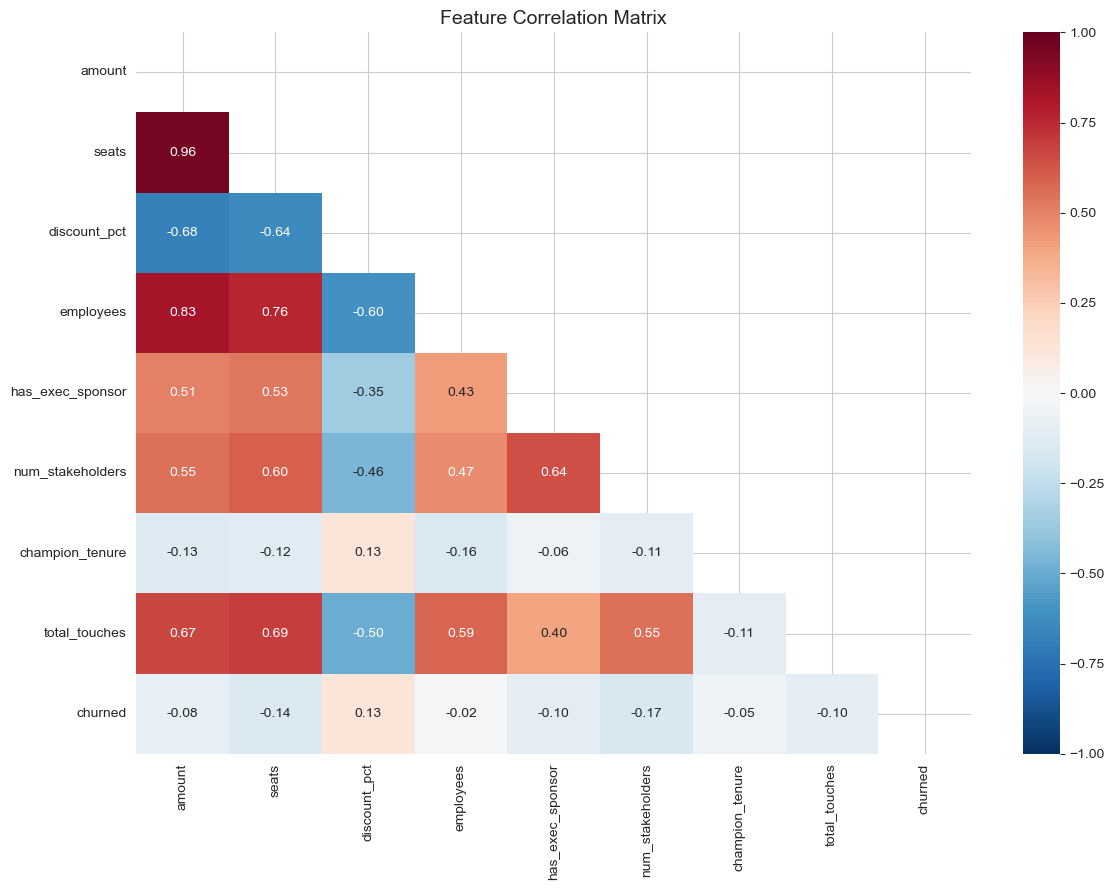

In [15]:
numeric_cols = ['amount', 'seats', 'discount_pct', 'employees',
                'has_exec_sponsor', 'num_stakeholders', 'champion_tenure',
                'total_touches', 'churned']

fig, ax = plt.subplots(figsize=(12, 9))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()


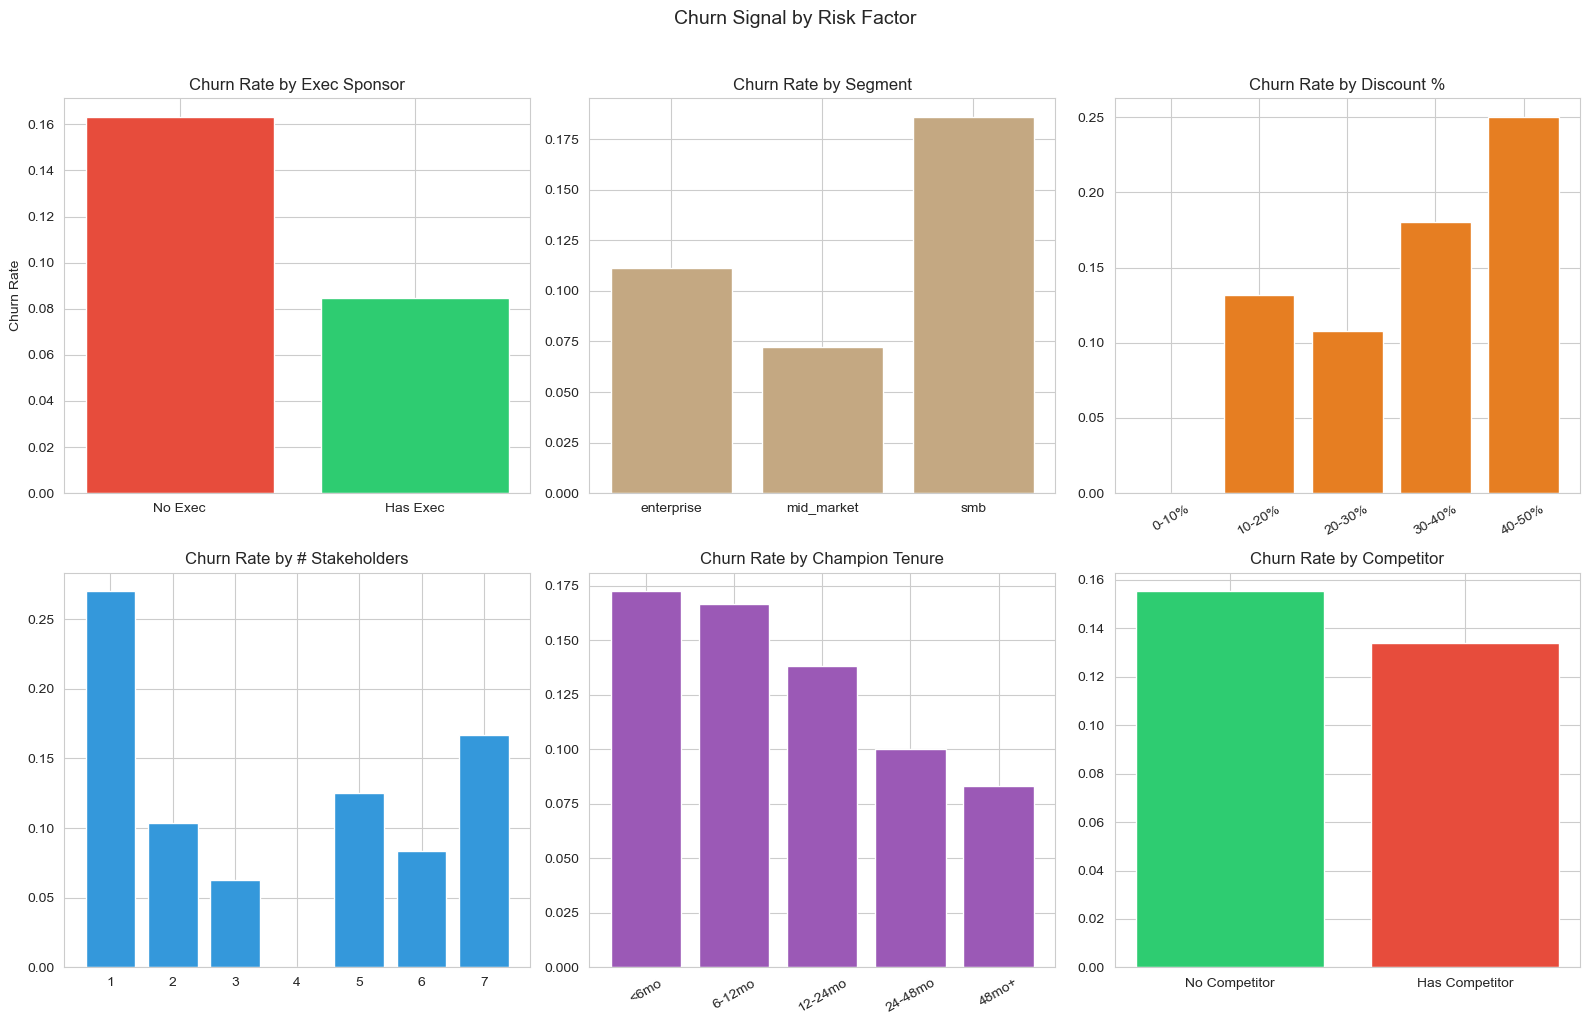

In [16]:
# Churn rate by key risk factors
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

churn_by_exec = df.groupby('has_exec_sponsor')['churned'].mean()
axes[0,0].bar(['No Exec', 'Has Exec'], churn_by_exec.values, color=['#e74c3c', '#2ecc71'])
axes[0,0].set_title('Churn Rate by Exec Sponsor')
axes[0,0].set_ylabel('Churn Rate')

churn_by_seg = df.groupby('segment')['churned'].mean()
axes[0,1].bar(churn_by_seg.index, churn_by_seg.values, color='#C4A882')
axes[0,1].set_title('Churn Rate by Segment')

bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%']
df['discount_bin'] = pd.cut(df['discount_pct'], bins=bins, labels=labels)
churn_by_disc = df.groupby('discount_bin', observed=True)['churned'].mean()
axes[0,2].bar(churn_by_disc.index, churn_by_disc.values, color='#e67e22')
axes[0,2].set_title('Churn Rate by Discount %')
axes[0,2].tick_params(axis='x', rotation=30)

churn_by_stake = df.groupby('num_stakeholders')['churned'].mean()
axes[1,0].bar(churn_by_stake.index, churn_by_stake.values, color='#3498db')
axes[1,0].set_title('Churn Rate by # Stakeholders')

bins = [0, 6, 12, 24, 48, 200]
labels = ['<6mo', '6-12mo', '12-24mo', '24-48mo', '48mo+']
df['tenure_bin'] = pd.cut(df['champion_tenure'], bins=bins, labels=labels)
churn_by_tenure = df.groupby('tenure_bin', observed=True)['churned'].mean()
axes[1,1].bar(churn_by_tenure.index, churn_by_tenure.values, color='#9b59b6')
axes[1,1].set_title('Churn Rate by Champion Tenure')
axes[1,1].tick_params(axis='x', rotation=30)

churn_by_comp = df.groupby('has_competitor')['churned'].mean()
axes[1,2].bar(['No Competitor', 'Has Competitor'], churn_by_comp.values, color=['#2ecc71', '#e74c3c'])
axes[1,2].set_title('Churn Rate by Competitor')

plt.suptitle('Churn Signal by Risk Factor', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


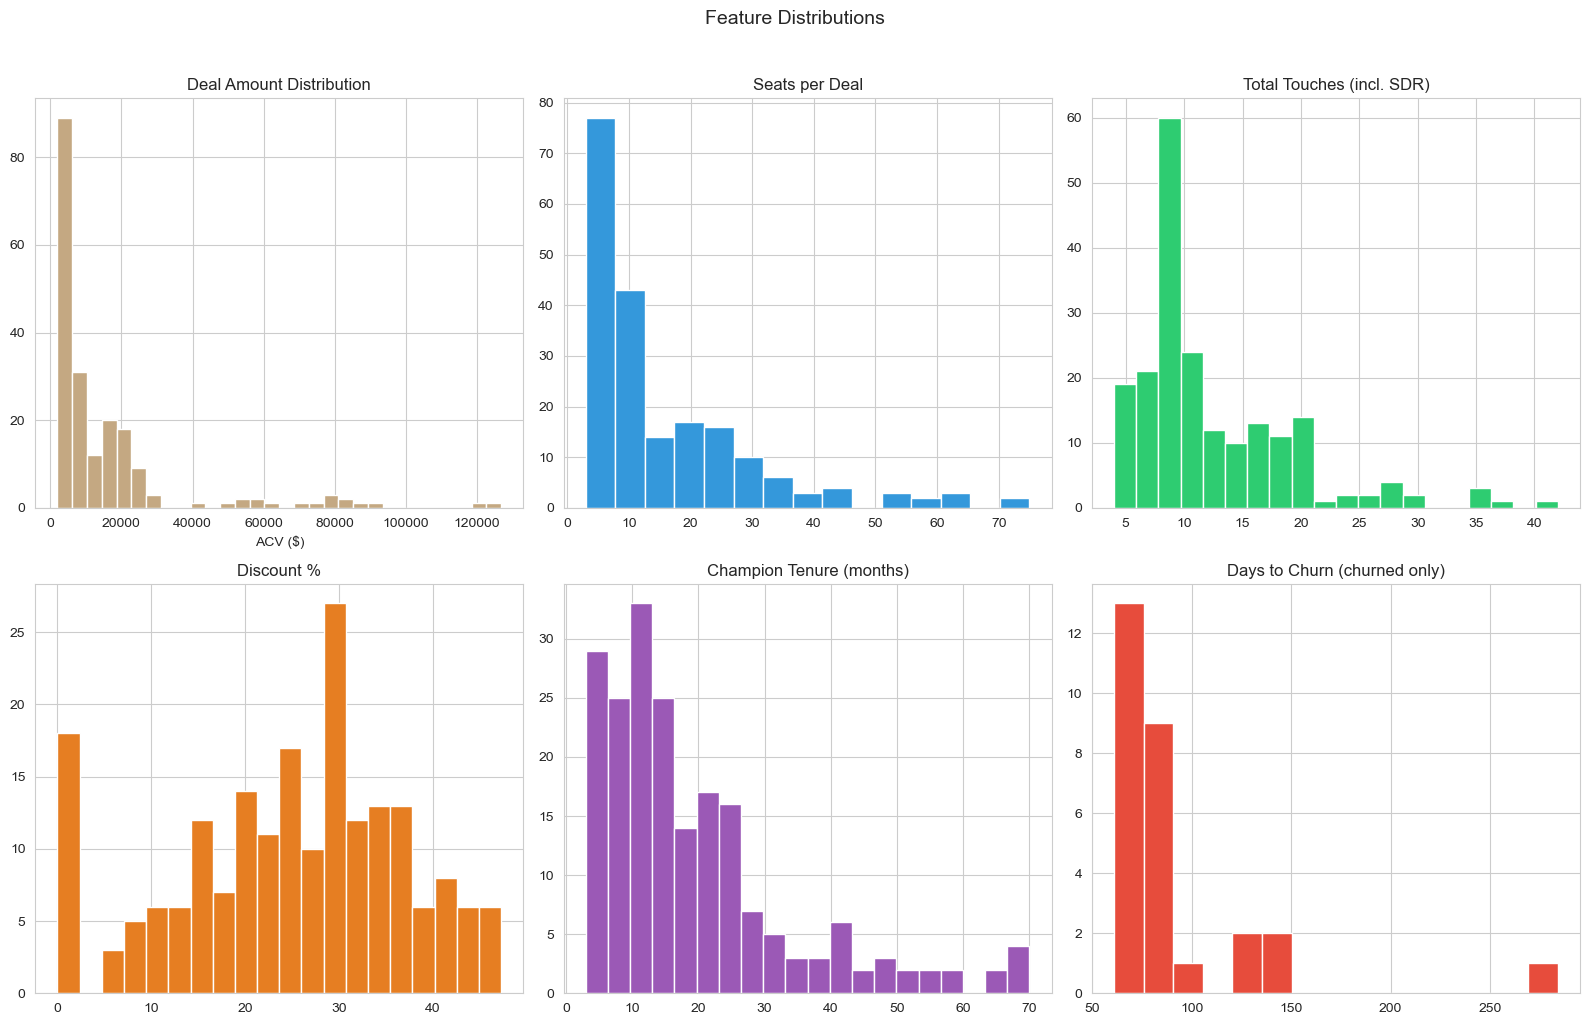

In [17]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].hist(df['amount'], bins=30, color='#C4A882', edgecolor='white')
axes[0,0].set_title('Deal Amount Distribution')
axes[0,0].set_xlabel('ACV ($)')

axes[0,1].hist(df['seats'], bins=15, color='#3498db', edgecolor='white')
axes[0,1].set_title('Seats per Deal')

axes[0,2].hist(df['total_touches'], bins=20, color='#2ecc71', edgecolor='white')
axes[0,2].set_title('Total Touches (incl. SDR)')

axes[1,0].hist(df['discount_pct'], bins=20, color='#e67e22', edgecolor='white')
axes[1,0].set_title('Discount %')

axes[1,1].hist(df['champion_tenure'], bins=20, color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Champion Tenure (months)')

churned_df = df[df['churned'] == True]
if len(churned_df) > 0:
    axes[1,2].hist(churned_df['days_to_churn'].dropna(), bins=15, color='#e74c3c', edgecolor='white')
axes[1,2].set_title('Days to Churn (churned only)')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Generate 1000 Training Deals

Generate 1000 deals with AskElephant AI-processed touch content.
Run this cell to populate `system/data/synthetic/`.

In [18]:
# Generate 1000 deals — resumable, one file per deal
# Re-run safely: skips already-generated deals
training_deals = generate_full_dataset(n_deals=1000, fill_content=True, base_seed=42)

print(f"\nTotal deals: {len(training_deals)}")
print(f"Total touches: {sum(len(d['touches']) for d in training_deals)}")
print(f"Churn rate: {sum(1 for d in training_deals if d['outcome']['status']=='churned')/len(training_deals):.1%}")


Generating deals:   0%|          | 0/1000 [00:00<?, ?it/s]


Skipped 1000 existing deals (resumed)
Generated 0 new deals
Total: 1000 deals in ../backend/data/synthetic/

Total deals: 1000
Total touches: 12678
Churn rate: 15.7%
